![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Ejemplo predicción conjunto de test para envío a Kaggle

En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [ ]:
# Predicción del conjunto de test - acá se genera un número aleatorio como ejemplo
#np.random.seed(42)
#y_pred = pd.DataFrame(np.random.rand(dataTesting.shape[0]) * 100, index=dataTesting.index, columns=['Popularity'])

# Guardar predicciones en formato exigido en la competencia de kaggle
#y_pred.to_csv('test_submission_file.csv', index_label='ID')
#y_pred.head()

In [1]:
# Importación librerías
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from IPython.display import Markdown, display
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn import metrics
import missingno as msno
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [2]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

#Eliminar variables que no vamos a usar
TrainingDrop = [dataTraining.columns[0], 'Unnamed: 0', 'track_id', 'track_name', 'album_name']
data_Training = dataTraining.drop(columns=TrainingDrop)
display(data_Training)

TestDrop = [dataTesting.columns[0], 'track_id', 'track_name', 'album_name']
data_Testing = dataTesting.drop(columns=TestDrop)
display(data_Testing)

,artists,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,Love and Rockets,211533,False,0.305,0.84900,9,-10.795,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,Filippa Giordano,196000,False,0.287,0.19000,7,-12.030,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,Susumu Yokota,216506,False,0.583,0.50900,1,-9.661,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,Franz Liszt;YUNDI,218346,False,0.163,0.03680,8,-23.149,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,Scooter,173160,False,0.647,0.92100,2,-7.294,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79795,Amilcare Ponchielli;Gothenburg Symphony Orches...,162613,False,0.554,0.00763,4,-30.566,1,0.0502,0.915000,0.000970,0.2210,0.1560,119.502,4,opera,49
79796,Sajanka,240062,False,0.689,0.55400,9,-8.200,1,0.0759,0.091000,0.914000,0.0867,0.1630,148.002,4,trance,30
79797,Frankie Valli & The Four Seasons,136306,False,0.629,0.56000,0,-11.455,0,0.0523,0.595000,0.000000,0.1820,0.8800,118.895,3,soul,0
79798,The Mayries,216841,False,0.421,0.10700,6,-15.191,1,0.0335,0.948000,0.000000,0.0881,0.1180,104.218,4,acoustic,44


,artists,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Hillsong Worship,440247,False,0.369,0.598,7,-6.984,1,0.0304,0.005110,0.000000,0.176,0.0466,148.014,4,world-music
1,Internal Rot,93933,False,0.171,0.997,7,-3.586,1,0.1180,0.005210,0.801000,0.420,0.0294,122.223,4,grindcore
2,Zhoobin Askarieh;Ali Sasha,213578,False,0.173,0.803,9,-10.071,0,0.1440,0.613000,0.001910,0.195,0.0887,75.564,3,iranian
3,Bryan Adams,151387,False,0.683,0.511,6,-5.598,1,0.0279,0.406000,0.000197,0.111,0.5980,109.991,3,rock
4,Nogizaka46,236293,False,0.555,0.941,9,-3.294,0,0.0481,0.484000,0.000000,0.266,0.8130,92.487,4,j-idol
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34195,Mickie Krause,216650,False,0.597,0.980,7,-2.075,1,0.0636,0.004270,0.000035,0.293,0.6330,139.989,4,german
34196,Fábio Jr.,219493,False,0.454,0.367,0,-12.251,1,0.0285,0.137000,0.000029,0.171,0.1420,113.250,4,mpb
34197,Imanbek;KDDK;KIDDO;Wiz Khalifa,165333,True,0.687,0.915,0,-1.342,1,0.0411,0.021000,0.000006,0.151,0.2720,89.962,4,house
34198,The Gathering,293040,False,0.362,0.668,0,-9.578,1,0.0432,0.000406,0.009400,0.131,0.1580,122.234,4,goth


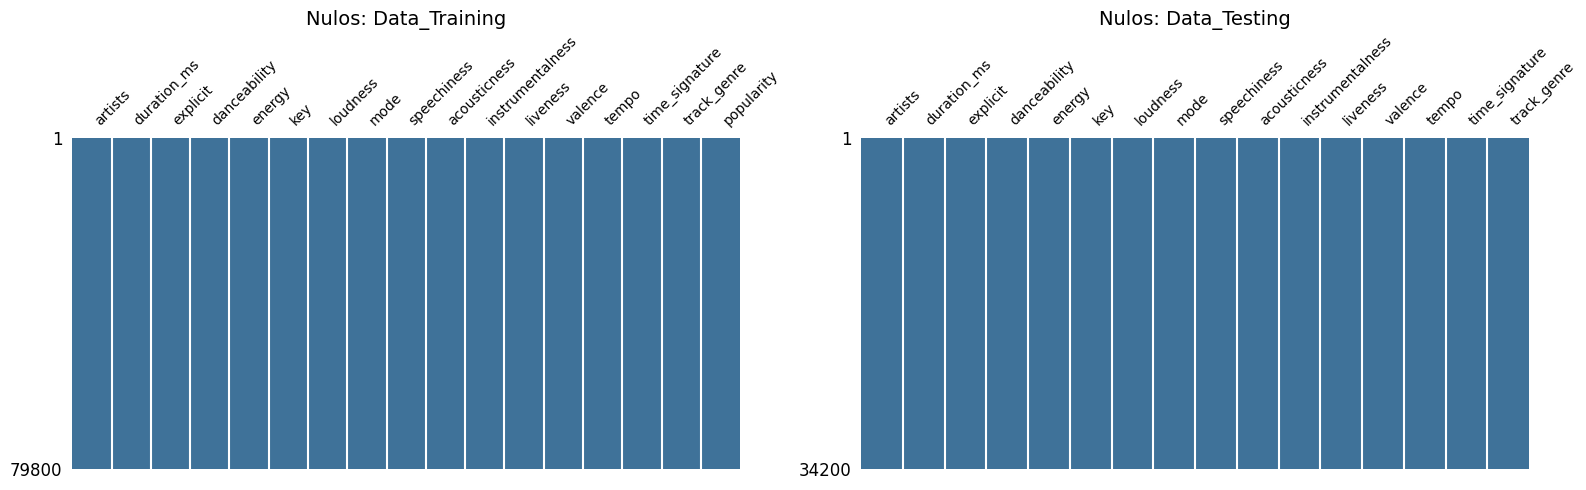

Se tienen 0 valores nulos en los datos de Training 

,artists,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity


Se tienen 1 valores nulos en los datos de Testing 

El valor nulo encontrado, se corrige para mostrar ***artist: Unknown***

Los nuevos valores nulos para los datos de Testing son 0 

In [3]:
#Se validan nulos
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
msno.matrix(data_Training, ax=ax[0], color=(0.25, 0.45, 0.6), fontsize=10, sparkline=False)
ax[0].set_title("Nulos: Data_Training", fontsize=14)
msno.matrix(data_Testing, ax=ax[1], color=(0.25, 0.45, 0.6), fontsize=10, sparkline=False)
ax[1].set_title("Nulos: Data_Testing", fontsize=14)
plt.tight_layout()
plt.show()

null_Training = data_Training.isnull().sum().sum()
nulos_Training = data_Training[data_Training.isnull().any(axis=1)]
display(Markdown(f"""Se tienen {null_Training} valores nulos en los datos de Training """))
display(nulos_Training)

null_Testing = data_Testing.isnull().sum().sum()
nulos_Testing = data_Testing[data_Testing.isnull().any(axis=1)]
display(Markdown(f"""Se tienen {null_Testing} valores nulos en los datos de Testing """))

display(Markdown(f"""El valor nulo encontrado, se corrige para mostrar ***artist: Unknown***"""))
data_Testing['artists'] = data_Testing['artists'].fillna('Unknown')

null_Testing = data_Testing.isnull().sum().sum()
nulos_Testing = data_Testing[data_Testing.isnull().any(axis=1)]
display(Markdown(f"""Los nuevos valores nulos para los datos de Testing son {null_Testing} """))

In [4]:
#Creamos una vriable binaria que nos dice si la canción es de una colaboración o no: 1 si contiene ';', 0 si no.
data_Training['is_collaboration'] = data_Training['artists'].str.contains(';').astype(int)
data_Testing['is_collaboration'] = data_Testing['artists'].str.contains(';').astype(int)

# Convertimos a valores numericos los valores de la columna explicit
data_Training['explicit'] = data_Training['explicit'].astype(int)
data_Testing['explicit'] = data_Testing['explicit'].astype(int)

# Se dividen los datos en predictores y variable de interés
y_Training = data_Training['popularity']
X_Training = data_Training.drop(['popularity'], axis=1)

# Se dividen los datos de Training en Train y Validation
X_train, X_val, y_train, y_val = train_test_split(X_Training, y_Training, test_size=0.2, random_state=42)

In [5]:
# Creamos una variable que contenga el promedio de la popularidad por artista
# Para los casos en donde hay colaborciones, se "duplica" la columna, teniendo cada artista en una fila nueva y así calculando el promedio de popularidad de una mejor manera
train_exploded = X_train[['artists']].assign(artists=X_train['artists'].str.split(';')).explode('artists')
train_exploded['popularity'] = y_train 

# Se calcula el promedio de popularidad por artista
diccionario_artistas = train_exploded.groupby('artists')['popularity'].mean()
display(diccionario_artistas.head())

# Se calcula el promedio de popularidad general
global_mean = y_train.mean()

# Se asigna la popularidad promedio a cada artista como un valor en nueva columna. Se tienen 3 casos:
# 1. La canción pertencene a solo un artista, por lo que busca su popularidad promedio y se asigna ese valor
# 2. La canción pertence a más de un artista, por lo que sebusca la popularidad de cada artista de la colaboración y se promedia el resultado
# 3. L acanción pertence a un artista que no esta en el set de datos de Train, para esos casos, se asigna el promedio global
                                                                                                      
def obtener_fama(lista_artistas):
    popularidad = [diccionario_artistas.get(a.strip(), global_mean) for a in lista_artistas]
    return sum(popularidad) / len(popularidad)

X_train['artist_popularity_avg'] = X_train['artists'].str.split(';').apply(obtener_fama)
X_val['artist_popularity_avg'] = X_val['artists'].str.split(';').apply(obtener_fama)
data_Testing['artist_popularity_avg'] = data_Testing['artists'].str.split(';').apply(obtener_fama)

#Se elimina la columna original de artista
X_train.drop(columns=['artists'], inplace=True)
X_val.drop(columns=['artists'], inplace=True)
data_Testing.drop(columns=['artists'], inplace=True)

artists
!nvite                                         23.0
"Cats" 1983 Broadway Cast                      26.5
"Pepo" San Martín                              21.0
"Puppy Dog Pals" Cast                          55.0
"The Phantom Of The Opera" 1990 German Cast    24.0
Name: popularity, dtype: float64

In [6]:
# Creamos una variable para cada genero, para poder separar el impacto por género
X_train = X_train.join(pd.get_dummies(X_train['track_genre'], prefix='G', dtype=int))
X_val = X_val.join(pd.get_dummies(X_val['track_genre'], prefix='G', dtype=int))
data_Testing = data_Testing.join(pd.get_dummies(data_Testing['track_genre'], prefix='G', dtype=int))

# Eliminamos la columna original porque ya no la necesitamos
X_train.drop(columns=['track_genre'], inplace=True)
X_val.drop(columns=['track_genre'], inplace=True)
data_Testing.drop(columns=['track_genre'], inplace=True)

G_sad                  594
G_trance               594
G_singer-songwriter    589
G_mpb                  587
G_disco                587
dtype: int64

G_idm      527
G_house    526
G_j-pop    526
G_rock     525
G_blues    524
dtype: int64

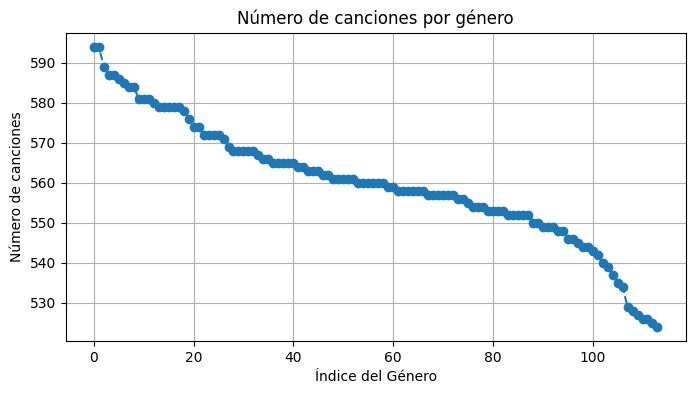

In [7]:
# Después de crear las variables para cada genero se observa la representatividad de cada una dentro del dataset para poder evaluar si es pertinente agrupar generos
generos_cols = [col for col in X_train.columns if col.startswith('G_')]
frecuencias = X_train[generos_cols].sum().sort_values(ascending=False)
display(frecuencias.head())
display(frecuencias.tail())

plt.figure(figsize=(8, 4))
plt.plot(range(len(frecuencias)), frecuencias.values, marker='o', linestyle='--')
plt.title("Número de canciones por género")
plt.xlabel("Índice del Género")
plt.ylabel("Número de canciones")
plt.grid(True)
plt.show()

# Se observa que los generos tienen entre 524 a 594  filas dntro del dataset de train, por lo cual se tiene un buen balanceo de generos y se mantendrá la información como ya se tiene

In [8]:
# Mostramos las estadísticas descriptivas de las variables (excepto las de genero)
pd.set_option('display.max_columns', None)
display(X_train[[col for col in X_train.columns if not col.startswith('G_')]].describe())

,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,is_collaboration,artist_popularity_avg
count,6.384000e+04,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000
mean,2.281033e+05,0.085981,0.567225,0.641087,5.305874,-8.264046,0.638330,0.084840,0.315020,0.157435,0.213265,0.473802,122.002601,3.900862,0.264395,33.386428
std,1.077960e+05,0.280338,0.173286,0.251416,3.565742,5.036530,0.480488,0.106001,0.332806,0.310653,0.189900,0.259263,29.947987,0.438222,0.441014,17.602067
min,1.338600e+04,0.000000,0.000000,0.000019,0.000000,-49.307000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.746490e+05,0.000000,0.456000,0.472000,2.000000,-9.992250,0.000000,0.035900,0.016900,0.000000,0.097900,0.261000,99.025500,4.000000,0.000000,20.760870
50%,2.126930e+05,0.000000,0.580000,0.685000,5.000000,-7.018000,1.000000,0.049000,0.168000,0.000041,0.132000,0.463000,122.001000,4.000000,0.000000,33.500000
75%,2.615190e+05,0.000000,0.695000,0.853000,8.000000,-5.004750,1.000000,0.084500,0.598000,0.051125,0.274000,0.684000,140.047000,4.000000,1.000000,46.110276
max,5.237295e+06,1.000000,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,0.997000,0.995000,222.605000,5.000000,1.000000,99.000000


In [9]:
# La variable duration_ms tiene una escala muy grande, la cual puede generar problemas para algunos modelos (por ejemplo regresiones lineales), por lo que se pasa a minutos
X_train['duration_min'] = X_train['duration_ms'] / 60000
X_val['duration_min'] = X_val['duration_ms'] / 60000
data_Testing['duration_min'] = data_Testing['duration_ms'] / 60000

# Eliminamos la columna original duration_ms
X_train.drop(columns=['duration_ms'], inplace=True)
X_val.drop(columns=['duration_ms'], inplace=True)
data_Testing.drop(columns=['duration_ms'], inplace=True)

pd.set_option('display.max_columns', None)
display(X_train[[col for col in X_train.columns if not col.startswith('G_')]].describe())

,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,is_collaboration,artist_popularity_avg,duration_min
count,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000,63840.000000
mean,0.085981,0.567225,0.641087,5.305874,-8.264046,0.638330,0.084840,0.315020,0.157435,0.213265,0.473802,122.002601,3.900862,0.264395,33.386428,3.801721
std,0.280338,0.173286,0.251416,3.565742,5.036530,0.480488,0.106001,0.332806,0.310653,0.189900,0.259263,29.947987,0.438222,0.441014,17.602067,1.796599
min,0.000000,0.000000,0.000019,0.000000,-49.307000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.223100
25%,0.000000,0.456000,0.472000,2.000000,-9.992250,0.000000,0.035900,0.016900,0.000000,0.097900,0.261000,99.025500,4.000000,0.000000,20.760870,2.910817
50%,0.000000,0.580000,0.685000,5.000000,-7.018000,1.000000,0.049000,0.168000,0.000041,0.132000,0.463000,122.001000,4.000000,0.000000,33.500000,3.544883
75%,0.000000,0.695000,0.853000,8.000000,-5.004750,1.000000,0.084500,0.598000,0.051125,0.274000,0.684000,140.047000,4.000000,1.000000,46.110276,4.358650
max,1.000000,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,0.997000,0.995000,222.605000,5.000000,1.000000,99.000000,87.288250


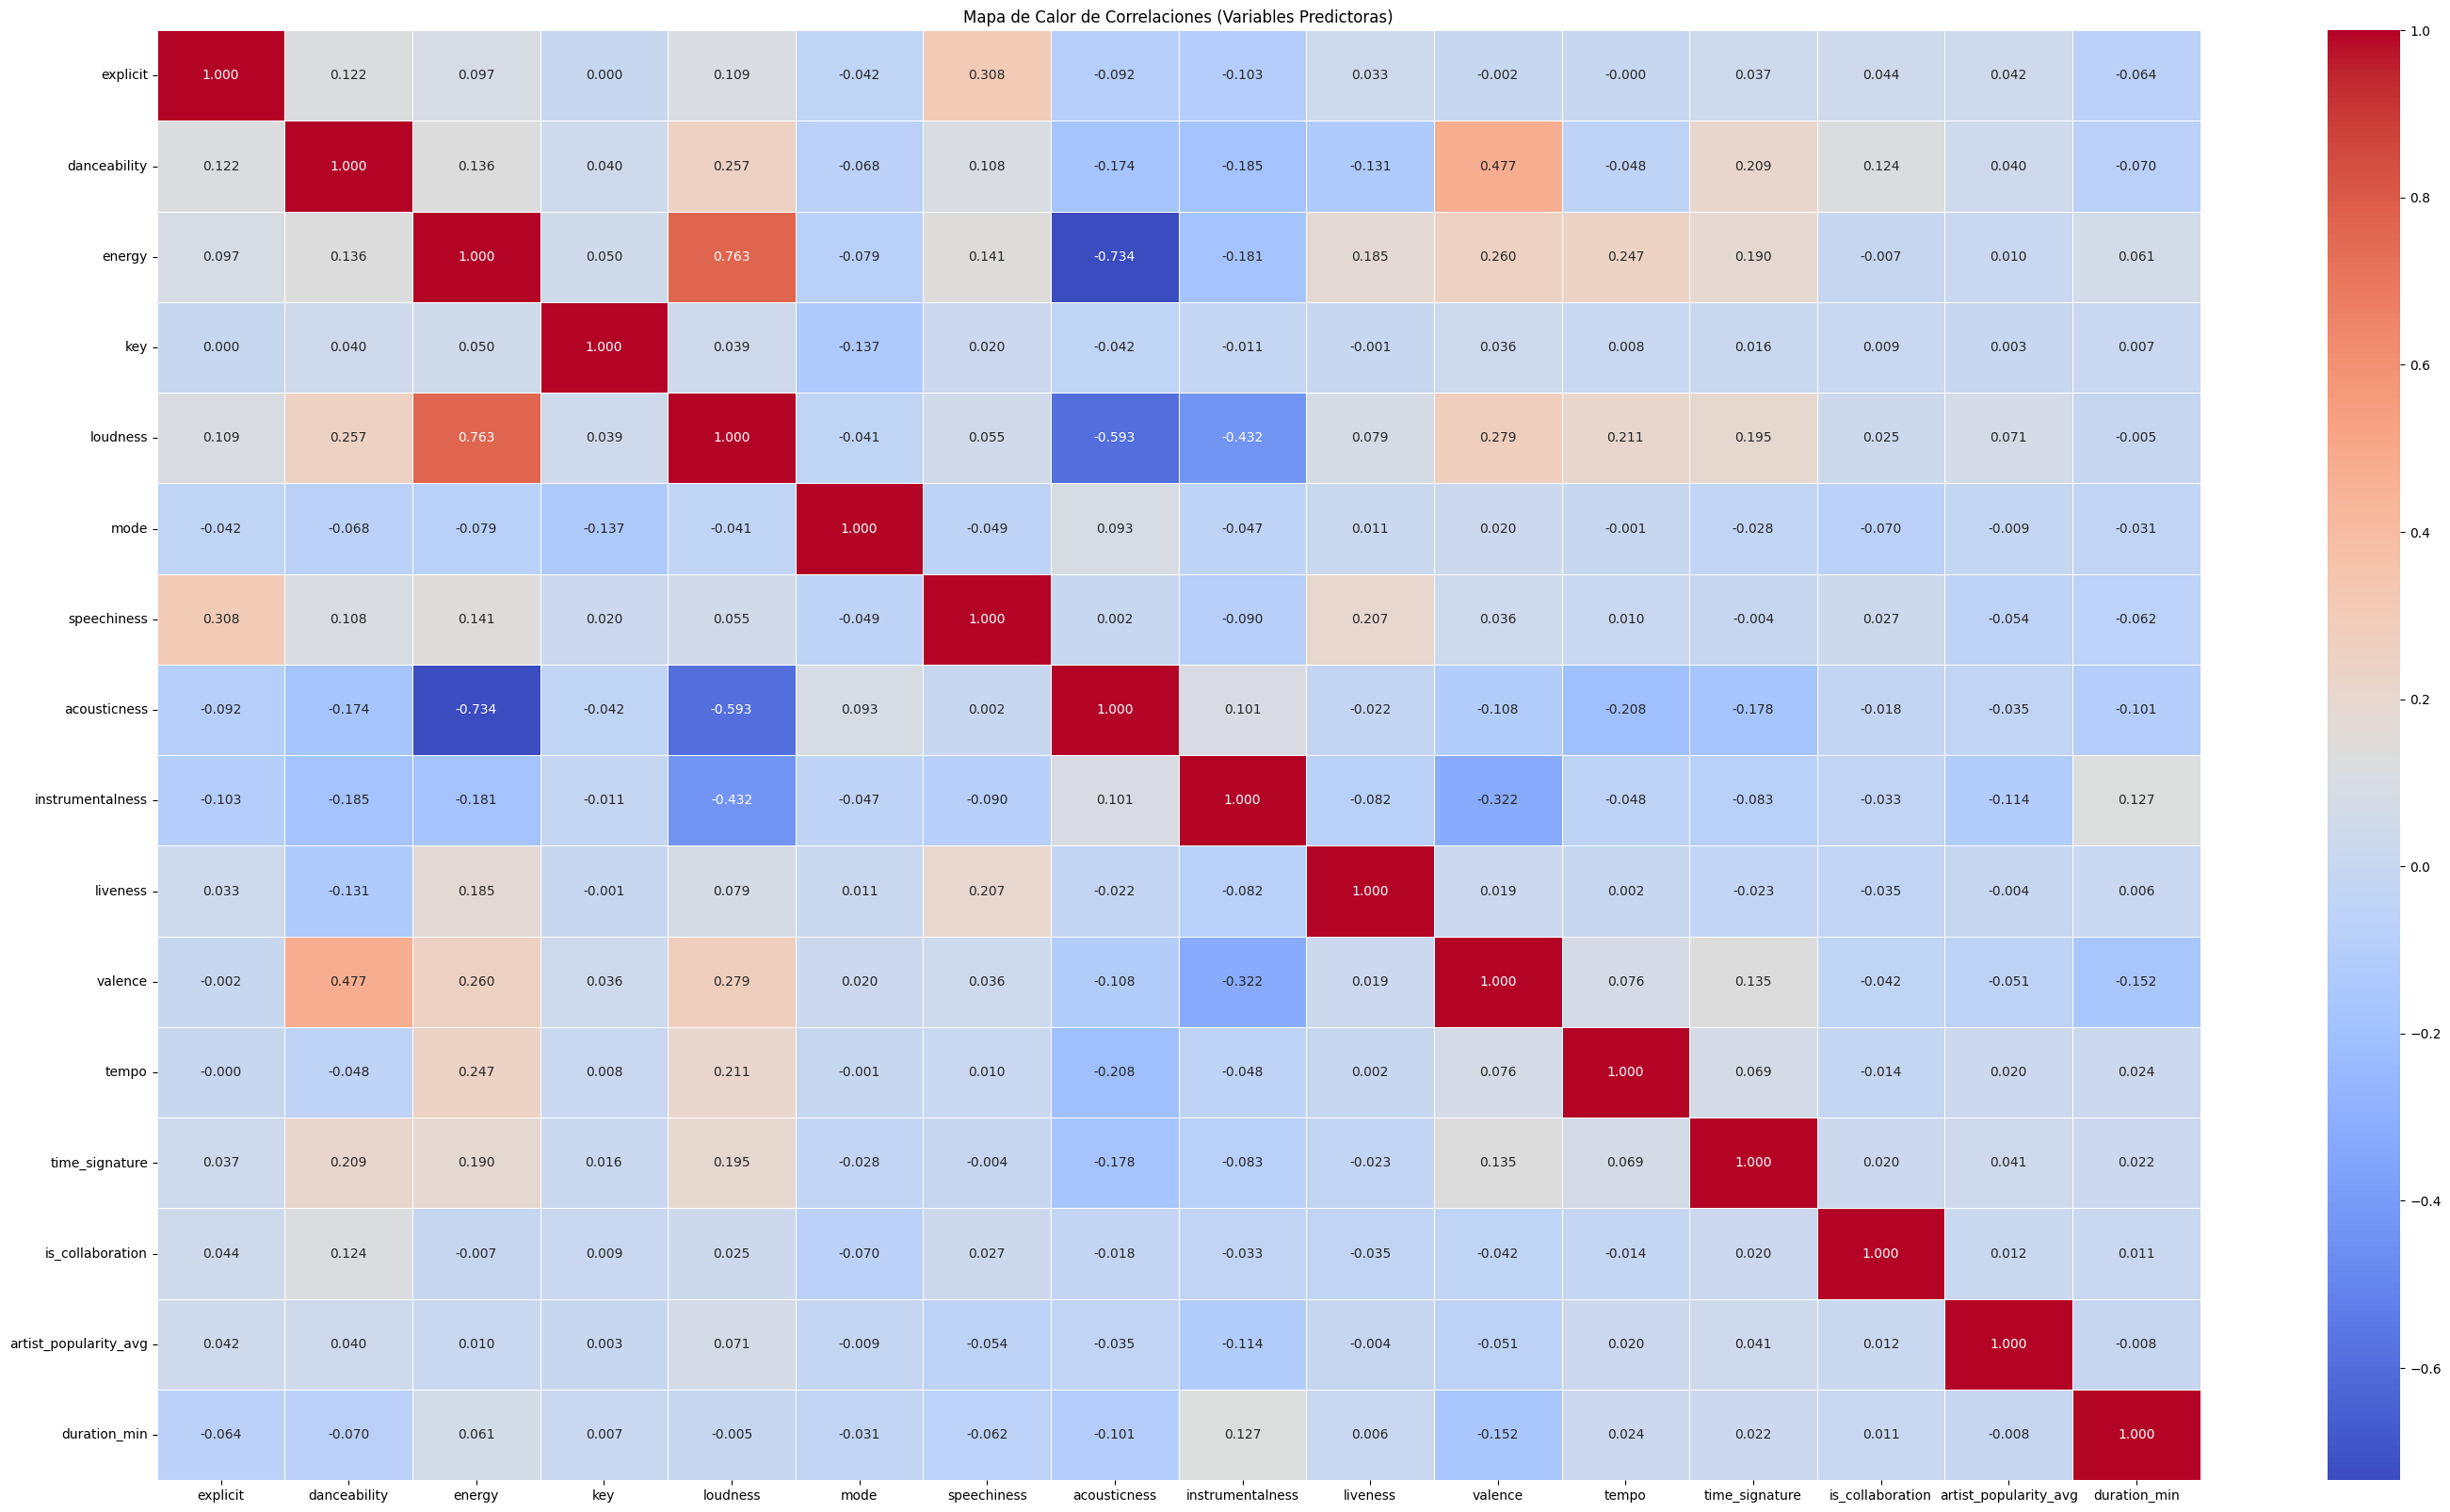

In [10]:
# Hacemos un mapa de calor para poder ver las correlaciones entre variables
plt.figure(figsize=(35, 20))
sns.heatmap(X_train[[col for col in X_train.columns if not col.startswith('G_')]].corr(), annot=True, cmap = "coolwarm", fmt=".3f", linewidths = 0.5)
plt.title("Mapa de Calor de Correlaciones (Variables Predictoras)")
plt.show()

# Se puede observar que las variables energy - loudenss y acousticness - energy tiene correlaciones altas con valores de 0.7 y -0.7 respectivamente, las cuales se deciden dejar como están
# dado que no representan un problema para modelos basados en árboles de decisión. 

In [11]:
# Calculamos la importancia de cada vairable mediante la implementación de un metodo de filtrado de mutual_information
pd.set_option('display.max_rows', None)

discrete_features = [X_train.columns.get_loc(col) for col in X_train.columns if col.startswith('G_') or col in ['explicit', 'is_collaboration', 'mode', 'key', 'time_signature']]
puntajes = mutual_info_regression(X_train, y_train, discrete_features=discrete_features, random_state=42)
mi_df = pd.DataFrame({'Variable': X_train.columns, 'Puntaje_MI': puntajes})
mi_df = mi_df.sort_values(by='Puntaje_MI', ascending=False)
display(mi_df.head())
display(mi_df.tail())

threshold = 0
variables_filtro = mi_df[mi_df['Puntaje_MI'] > threshold]['Variable'].tolist()

display(Markdown(f"""Teniendo en cuenta los resultados del puntaje de cada variable, se decide establecer un threshold de **{threshold}** seleccionando todas las variables que superen
                 este valor. Por lo cual, se usarán todas las variables que resulten de ayuda en predecir si un correo es Spam, eliminando del análisis todas aquellas que tengan un puntaje 
                 de 0.
                 \n Las variables resultante a usar son: {variables_filtro}."""))

#Filtrar sets de entrenamiento y prueba
X_train_filtrado = X_train[variables_filtro]
X_val_filtrado = X_val[variables_filtro]
data_Testing_filtrado = data_Testing[variables_filtro]

,Variable,Puntaje_MI
14,artist_popularity_avg,1.337996
129,duration_min,0.275565
11,tempo,0.270315
4,loudness,0.255579
7,acousticness,0.208119


,Variable,Puntaje_MI
124,G_techno,0.002424
122,G_synth-pop,0.002309
125,G_trance,0.002105
58,G_groove,0.001922
5,mode,0.000000


Teniendo en cuenta los resultados del puntaje de cada variable, se decide establecer un threshold de **0** seleccionando todas las variables que superen
                 este valor. Por lo cual, se usarán todas las variables que resulten de ayuda en predecir si un correo es Spam, eliminando del análisis todas aquellas que tengan un puntaje 
                 de 0.
                 
 Las variables resultante a usar son: ['artist_popularity_avg', 'duration_min', 'tempo', 'loudness', 'acousticness', 'instrumentalness', 'energy', 'valence', 'speechiness', 'liveness', 'danceability', 'G_detroit-techno', 'G_grindcore', 'G_chicago-house', 'G_honky-tonk', 'G_kids', 'G_idm', 'G_tango', 'G_pop', 'G_breakbeat', 'G_salsa', 'G_comedy', 'G_sertanejo', 'G_mpb', 'G_black-metal', 'G_brazil', 'G_gospel', 'G_iranian', 'G_pop-film', 'G_dance', 'G_forro', 'G_samba', 'G_romance', 'G_turkish', 'G_latin', 'G_ska', 'G_drum-and-bass', 'G_pagode', 'G_rock', 'G_bluegrass', 'G_happy', 'G_heavy-metal', 'G_j-idol', 'G_electro', 'G_hip-hop', 'G_reggae', 'G_power-pop', 'G_reggaeton', 'G_r-n-b', 'G_soul', 'G_latino', 'G_alternative', 'G_party', 'G_afrobeat', 'G_hardcore', 'G_jazz', 'G_country', 'G_disney', 'G_chill', 'G_death-metal', 'G_k-pop', 'is_collaboration', 'G_opera', 'G_edm', 'G_indian', 'G_house', 'G_sad', 'G_goth', 'G_rock-n-roll', 'G_j-dance', 'G_sleep', 'G_punk-rock', 'G_new-age', 'G_french', 'G_hardstyle', 'G_alt-rock', 'G_study', 'G_classical', 'G_swedish', 'G_guitar', 'G_j-rock', 'G_malay', 'G_mandopop', 'G_spanish', 'G_club', 'time_signature', 'G_metal', 'G_funk', 'G_garage', 'G_industrial', 'G_dubstep', 'G_show-tunes', 'G_trip-hop', 'G_disco', 'G_punk', 'explicit', 'G_metalcore', 'G_indie', 'G_anime', 'G_cantopop', 'G_j-pop', 'G_deep-house', 'G_emo', 'G_hard-rock', 'G_rockabilly', 'key', 'G_progressive-house', 'G_psych-rock', 'G_ambient', 'G_grunge', 'G_blues', 'G_acoustic', 'G_folk', 'G_dub', 'G_indie-pop', 'G_world-music', 'G_minimal-techno', 'G_british', 'G_dancehall', 'G_german', 'G_singer-songwriter', 'G_songwriter', 'G_children', 'G_electronic', 'G_piano', 'G_techno', 'G_synth-pop', 'G_trance', 'G_groove'].

# Random Forest

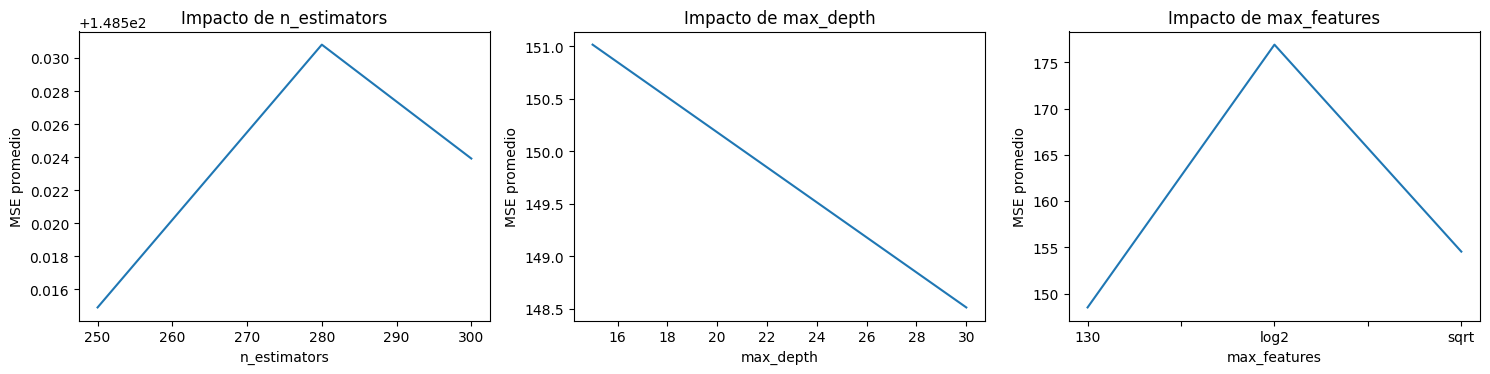

**Mejores parámetros encontrados:**
- n_estimators = 250
- max_depth = 30
- max_features = 130
MSE mínimo: 148.5149

In [ ]:
param_grid = {'n_estimators': [250, 280, 300], 'max_depth': [15, 30], 'max_features': ['sqrt', 'log2', len(X_train.columns)]}
clf = RandomForestRegressor(random_state=40, n_jobs=-1)
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='neg_mean_squared_error',n_jobs=-1)
grid_search.fit(X_train_filtrado, y_train)
best_params = grid_search.best_params_
best_mse = -grid_search.best_score_

results = pd.DataFrame(grid_search.cv_results_)
results['mean_mse'] = -results['mean_test_score']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Impacto de n_estimators
results[(results['param_max_depth'] == best_params['max_depth']) & (results['param_max_features'] == best_params['max_features'])].groupby('param_n_estimators')['mean_mse'].mean().plot(ax=axes[0])
axes[0].set_title('Impacto de n_estimators')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('MSE promedio')
# Impacto de max_depth
results[(results['param_n_estimators'] == best_params['n_estimators']) & (results['param_max_features'] == best_params['max_features'])].groupby('param_max_depth')['mean_mse'].mean().plot(ax=axes[1])
axes[1].set_title('Impacto de max_depth')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('MSE promedio')
# Impacto de max_features
results[(results['param_n_estimators'] == best_params['n_estimators']) & (results['param_max_depth'] == best_params['max_depth'])].groupby('param_max_features')['mean_mse'].mean().plot(ax=axes[2])
axes[2].set_title('Impacto de max_features')
axes[2].set_xlabel('max_features')
axes[2].set_ylabel('MSE promedio')

plt.tight_layout()
plt.show()

display(Markdown(f"""**Mejores parámetros encontrados:**
- n_estimators = {best_params['n_estimators']}
- max_depth = {best_params['max_depth']}
- max_features = {best_params['max_features']}
MSE mínimo: {best_mse:.4f}"""))

In [30]:
clf_random5_2 = RandomForestRegressor(max_depth=30,max_features=130,n_estimators=250,random_state=40)
clf_random5_2.fit(X_train_filtrado, y_train)

y_pred_random5_2 = clf_random5_2.predict(X_val_filtrado)
mae_random5_2 = metrics.mean_absolute_error(y_val, y_pred_random5_2)
mse_random5_2 = metrics.mean_squared_error(y_val, y_pred_random5_2)
rmse_random5_2 = np.sqrt(mse_random5_2)

display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un RMSE de {rmse_random5_2:.4f}, un MAE de {mae_random5_2:.4f} y MSE de {mse_random5_2:.4f}"""))

Se obtiene que el modelo resultante cuenta con un RMSE de 14.0584, un MAE de 8.4364 y MSE de 197.6395

In [ ]:
# max_depth=7,max_features=47,n_estimators=150
# Se obtiene que el modelo resultante cuenta con un RMSE de 15.0516, un MAE de 10.0353 y MSE de 226.5505

# max_depth=8,max_features=130,n_estimators=200
# Se obtiene que el modelo resultante cuenta con un RMSE de 14.8269, un MAE de 9.3816 y MSE de 219.8372
# MSE de entrenamiento de 155.8846

# max_depth=30,max_features=130,n_estimators=250
# Se obtiene que el modelo resultante cuenta con un RMSE de 14.0584, un MAE de 8.4364 y MSE de 197.6395
# MSE de entrenamiento de 148.5149

# Al evaluar los resultados de diferentes calibraciones obtenidas en Train y ver su resultado en test, se decide usar la configuración que contempla una profundidad de 30, dado que a pesar
# de ser un número muy grande y ser propenso a overfitting, es el que mejor esta capturando el comportamiento no lineal de los datos de popularidad para las canciones de spotify, lo cual se 
# puede ver al obversar el rmse y mae obtenido al evaluar en los datos de validadción, en donde se obtienen los menores valores posibles RMSE 14.05 y MAE 8.4.

In [33]:
y_pred_test = clf_random5_2.predict(data_Testing_filtrado)
y_pred_test_final = pd.DataFrame(y_pred_test, index=data_Testing_filtrado.index, columns=['Popularity'])
y_pred_test_final.to_csv('Random_Forest.csv', index_label='ID')
y_pred_test_final.head()

,Popularity
0,45.120052
1,13.483472
2,0.000000
3,0.439532
4,25.315987


# XGBOOST

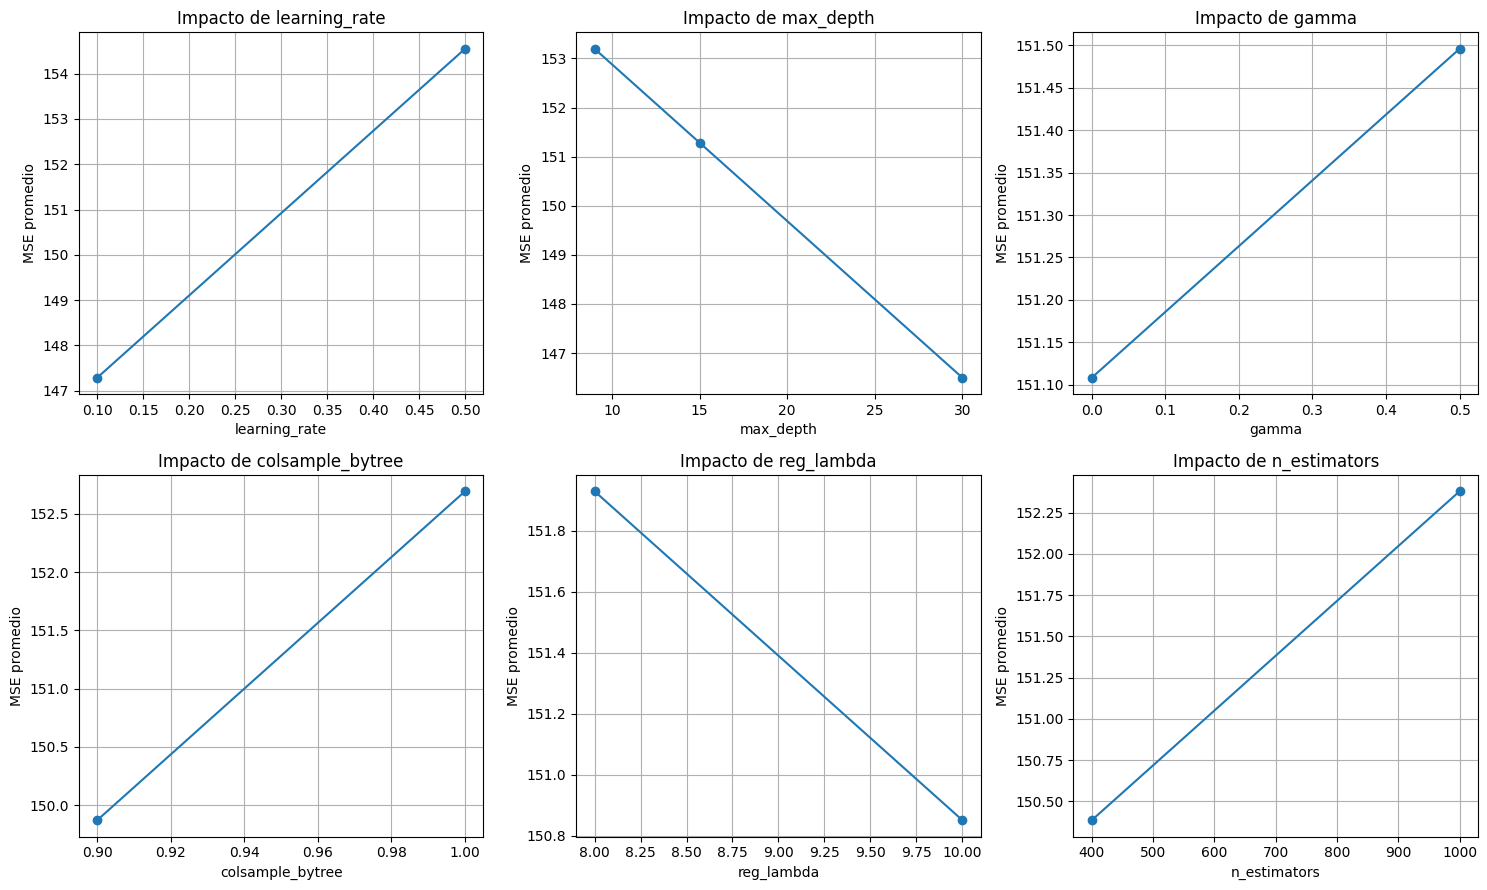

**Mejores parámetros encontrados:**
- learning_rate = 0.1
- max_depth = 30
- gamma = 0.5
- colsample_bytree = 0.9
- reg_lambda = 10
- n_estimators = 400
MSE mínimo: 143.8221

In [12]:
param_grid = {
    'learning_rate': [0.1, 0.5],
    'max_depth': [9, 15, 30],
    'gamma': [0, 0.5],
    'colsample_bytree': [0.9, 1.0],
    'reg_lambda': [8, 10],
    'n_estimators': [400, 1000] 
}

clf = XGBRegressor(early_stopping_rounds=10, random_state=60, n_jobs=-1)
random_search = RandomizedSearchCV(clf, param_distributions=param_grid, n_iter=20, cv=3, scoring='neg_mean_squared_error', random_state=40, n_jobs=-1)
random_search.fit(X_train_filtrado, y_train, eval_set=[(X_val_filtrado, y_val)], verbose=False)
best_params = random_search.best_params_
best_mse = -random_search.best_score_

results = pd.DataFrame(random_search.cv_results_)
results['mean_mse'] = -results['mean_test_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes_flat = axes.flatten()
parametros = ['learning_rate', 'max_depth', 'gamma', 'colsample_bytree', 'reg_lambda', 'n_estimators']

for i, param in enumerate(parametros):
    col_name = f'param_{param}'
    results.groupby(col_name)['mean_mse'].mean().plot(kind='line', marker='o', ax=axes_flat[i])
    axes_flat[i].set_title(f'Impacto de {param}')
    axes_flat[i].set_xlabel(param)
    axes_flat[i].set_ylabel('MSE promedio')
    axes_flat[i].grid(True)

plt.tight_layout()
plt.show()

display(Markdown(f"""**Mejores parámetros encontrados:**
- learning_rate = {best_params['learning_rate']}
- max_depth = {best_params['max_depth']}
- gamma = {best_params['gamma']}
- colsample_bytree = {best_params['colsample_bytree']}
- reg_lambda = {best_params['reg_lambda']}
- n_estimators = {best_params['n_estimators']}
MSE mínimo: {best_mse:.4f}"""))

In [18]:
clf_random_xgb = XGBRegressor(early_stopping_rounds=10, learning_rate=0.1 , max_depth=30, gamma=0.5, colsample_bytree=0.9, reg_lambda=10, 
                              n_estimators=400, random_state=60, n_jobs=-1)
clf_random_xgb.fit(X_train_filtrado, y_train, eval_set=[(X_val_filtrado, y_val)], verbose=False)
y_pred_xgb = clf_random_xgb.predict(X_val_filtrado)

mae_random_xgb= metrics.mean_absolute_error(y_val, y_pred_xgb)
mse_random_xgb = metrics.mean_squared_error(y_val, y_pred_xgb)
rmse_random_xgb = np.sqrt(mse_random_xgb)

display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un RMSE de {rmse_random_xgb:.4f}, un MAE de {mae_random_xgb:.4f} y MSE 
                 de {mse_random_xgb:.4f}"""))

Se obtiene que el modelo resultante cuenta con un RMSE de 13.6795, un MAE de 8.0298 y MSE 
                 de 187.1276

In [ ]:
# learning_rate=0.1 , max_depth=9, gamma=0, colsample_bytree=1, reg_lambda=10, n_estimators=1000
# Se obtiene que el modelo resultante cuenta con un RMSE de 14.0944, un MAE de 8.6060 y MSE de 198.6514
# MSE de entrenamiento de 149.3341

# learning_rate=0.1 , max_depth=30, gamma=0.5, colsample_bytree=0.9, reg_lambda=10, n_estimators=400
# Se obtiene que el modelo resultante cuenta con un RMSE de 13.6795, un MAE de 8.0298 y MSE de 187.1276
# MSE de entrenamiento de 143.8821

In [ ]:
y_pred_test_xgb = clf_random_xgb.predict(data_Testing_filtrado)
y_pred_test_final_xgb = pd.DataFrame(y_pred_test_xgb, index=data_Testing_filtrado.index, columns=['Popularity'])
y_pred_test_final_xgb.to_csv('XGBoost.csv', index_label='ID')
y_pred_test_final_xgb.head()